# CMM-VAE “ MSWEP DJF Holdout Notebook

**Differences from `cmmvae_mswep.ipynb`:**
- Temporal filter: **DJF only** (December, January, February)
- Number of clusters: **k = 4**
- Data split: **70 % training / 30 % holdout** (stratified, `random_state=42`)
- The 30 % holdout is kept **completely unseen** until final evaluation
- 5-Fold cross-validation is applied **only to the 70 % training set**
- Final BSS / Odds-Ratio are computed on the **unseen holdout set**

In [4]:
%load_ext autoreload
%autoreload 2

from keras.layers import Lambda, Input, Dense, Reshape, Dropout, Conv2D, Flatten
from keras.models import Model
from keras.losses import mse, binary_crossentropy
from keras.utils import plot_model

from keras.metrics import categorical_crossentropy

import tensorflow as tf
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split, KFold
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, mean_squared_error

import pandas as pd
import numpy as np
import xarray as xr

from scipy import stats
from math import ceil

import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import seaborn as sns

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
g0 = 9.80665
# DJF months only
djf_months = [12, 1, 2]

#### Parameters

In [6]:
import yaml
import os  # Moved this to the top
import random
import numpy as np
import tensorflow as tf

# --- Settings ---
cluster_number = 4
reconstruction_loss_factor = 0.5
filepath = "results/cmmvae_mswep_djf/"
pr_cluster_number = 4
original_dim = 825
inputdim1 = 25
inputdim2 = 33
latent_dim = 15
activation_function = 'relu'
dim_layer1 = 256
dim_layer2 = 128
dim_layer3 = 64
cat_dim = 1
batch_size = 128
epochs = 100
TRAIN_SIZE = 0.70
RANDOM_STATE = 42

# --- Seed Fixing ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(RANDOM_STATE)

# --- Final setup ---
os.makedirs(filepath, exist_ok=True)
print(f"Results will be saved to: {filepath}")


Results will be saved to: results/cmmvae_mswep_djf/


### Sampling function

In [7]:
def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(
        shape=(K.shape(z_mean)[0], K.int_shape(z_mean)[1]),
        mean=0., stddev=1.)
    return z_mean + K.exp(0.5 * z_log_sigma) * epsilon

### Data pre-processing

In [8]:
# Load ERA5 Z500 geopotential height (Atlantic region, DJF only)
z500 = pf.preprocess_dataset(
    filename            = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name       = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter = 'new atlantic',
    months_filter       = djf_months,   # DJF only
    anomalies           = True,
    normalization       = False,
    rolling_window      = 5)

# Restrict to MSWEP period: 1979-2020
z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

# Area weighting by cosine of latitude and standardisation
weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

z500_reshaped = cf.reshape_data_for_clustering(z500)
print(f"Z500 shape (DJF): {z500.shape}  â†’  reshaped: {z500_reshaped.shape}")

Z500 shape (DJF): (3791, 25, 33)  â†’  reshaped: (3791, 825)


In [9]:
# Load MSWEP precipitation cluster labels for DJF
# These files are generated by generate_mswep_files.py with DJF filter
pr_labels = pd.read_csv('../data.nosync/MSWEP_pr_cluster_labels_4_djf.csv')
pr_labels.columns = ['index', 'labels']

# Build one-hot label matrix  shape: (n_days, pr_cluster_number)
pr_labels['values'] = 1
label_indices_pd = pd.pivot_table(
    pr_labels, values='values', index=['index'],
    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

# Load 95th-percentile exceedance binary mask (DJF)
threshold_qn95 = xr.open_dataset('../data.nosync/MSWEP_pr_95pc_DJF.nc')
threshold_qn95 = threshold_qn95.where(
    threshold_qn95['time.year'] < 2021, drop=True)['precipitation']

# Load total precipitation (DJF)
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_DJF.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"Cluster label matrix: {label_indices.shape}")
print(f"Threshold mask shape: {threshold_qn95.shape}")
print(f"pr_spatial shape:     {pr_spatial.shape}")

assert z500.shape[0] == label_indices.shape[0], (
    f"Time mismatch! Z500={z500.shape[0]}, labels={label_indices.shape[0]}")
print("Time alignment OK.")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17764\2948993422.py:8: FutureWarning: The provided callable <function sum at 0x0000013B5A81FB50> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  label_indices_pd = pd.pivot_table(


Cluster label matrix: (3791, 4)
Threshold mask shape: (3791, 150, 160)
pr_spatial shape:     (3791, 150, 160)
Time alignment OK.


## Define model

**Encoder**

In [10]:
inputs_x  = Input(shape=input_shape,   name='encoder_input')
inputs_r  = Input(shape=input_shape_r, name='ground_truth')

inter_x1  = Dense(dim_layer1, activation=activation_function, name='encoder_intermediate')(inputs_x)
inter_x2  = Dense(dim_layer2, activation=activation_function, name='encoder_intermediate_2')(inter_x1)
inter_x3  = Dense(dim_layer3, activation=activation_function, name='encoder_intermediate_3')(inter_x2)

dummy      = Input(shape=(1,), name='dummy')
mu_vector  = Dense(cluster_number * latent_dim, name='mu_vector', use_bias=False)(dummy)
mu         = Reshape((cluster_number, latent_dim), name='mu')(mu_vector)

pi  = Dense(cluster_number, activation='softmax', name='pi')(dummy)
c   = Dense(cluster_number, activation='softmax', name='c')(inter_x3)

z_mean    = Dense(latent_dim, name='z_mean')(inter_x3)
z_log_var = Dense(latent_dim, name='z_log_var')(inter_x3)

r  = Dense(pr_cluster_number, name='r_label', activation='softmax')(inter_x3)
cr = Dense(cluster_number,    activation='softmax', name='cr')(r)

z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

encoder = Model(
    [inputs_x, dummy, inputs_r],
    [z_mean, z_log_var, z, mu, c, pi, r, cr],
    name='encoder')

encoder.summary()


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 encoder_intermediate (Dens  (None, 256)                  211456    ['encoder_input[0][0]']       
 e)                                                                                               
                                                                                                  
 encoder_intermediate_2 (De  (None, 128)                  32896     ['encoder_intermediate[0][0]']
 nse)                                                                                             
                                                                                           

**Decoder**

In [11]:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

inter_y1 = Dense(dim_layer3, activation=activation_function)(latent_inputs)
inter_y2 = Dense(dim_layer2, activation=activation_function)(inter_y1)
inter_y3 = Dense(dim_layer1, activation=activation_function)(inter_y2)

outputs  = Dense(original_dim)(inter_y3)

decoder  = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 15)]              0         
                                                                 
 dense (Dense)               (None, 64)                1024      
                                                                 
 dense_1 (Dense)             (None, 128)               8320      
                                                                 
 dense_2 (Dense)             (None, 256)               33024     
                                                                 
 dense_3 (Dense)             (None, 825)               212025    
                                                                 
Total params: 254393 (993.72 KB)
Trainable params: 254393 (993.72 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Combine encoder and decoder into the VAE model**

In [12]:
outputs = decoder(encoder([inputs_x, dummy, inputs_r])[2])
vae     = Model([inputs_x, dummy, inputs_r], outputs, name='vae_classification')
vae.summary()

Model: "vae_classification"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dummy (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 ground_truth (InputLayer)   [(None, 4)]                  0         []                            
                                                                                                  
 encoder (Functional)        [(None, 15),                 255166    ['encoder_input[0][0]',       
                              (None, 15),                            'dummy[0][0]

### Loss function

In [13]:
reconstruction_loss = mse(inputs_x, outputs) * original_dim * reconstruction_loss_factor
prediction_loss     = categorical_crossentropy(c, cr)
target_loss         = (categorical_crossentropy(inputs_r, r) +
                       categorical_crossentropy(r, r)) * pr_cluster_number

kl_loss_all  = tf.compat.v1.get_variable(
    "kl_loss_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)
kl_cat_all   = tf.compat.v1.get_variable(
    "kl_cat_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)
dir_prior_all = tf.compat.v1.get_variable(
    "dir_prior_all", [batch_size, 1], dtype=tf.float32,
    initializer=tf.zeros_initializer)

for i in range(cluster_number):
    kl_loss = 1 + z_log_var - tf.math.square(z_mean - mu[:, i, :]) - tf.math.exp(z_log_var)
    kl_loss = tf.multiply(tf.reduce_sum(kl_loss, axis=-1), c[:, i])
    kl_loss = -0.5 * kl_loss
    kl_loss_all = kl_loss_all + kl_loss

    mc      = tf.reduce_mean(c[:, i])
    mpi     = tf.reduce_mean(pi[:, i])
    kl_cat  = mc * tf.math.log(mc) - mc * tf.math.log(mpi)
    kl_cat_all = kl_cat_all + kl_cat

    dir_prior     = -tf.math.log(pi[:, i]) * 0.5
    dir_prior_all = dir_prior_all + dir_prior

**Compile model and save initial random weights**

In [14]:
vae_loss = K.mean(
    reconstruction_loss + prediction_loss + target_loss +
    kl_loss_all + kl_cat_all + dir_prior_all)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
vae.summary()

# Save initial random weights so every fold starts from the same point
vae.save_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')
print("Random weights saved.")


Model: "vae_classification"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dummy (InputLayer)          [(None, 1)]                  0         []                            
                                                                                                  
 ground_truth (InputLayer)   [(None, 4)]                  0         []                            
                                                                                                  
 encoder (Functional)        [(None, 15),                 255166    ['encoder_input[0][0]',       
                              (None, 15),                            'dummy[0][0

## Train model

In [15]:
X = cf.reshape_data_for_clustering(z500)   # (n_days, 825)
y = label_indices                           # (n_days, 4)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (3791, 825), y shape: (3791, 4)


#### 70 / 30 Train-Holdout Split

The 30 % holdout set is kept **completely unseen** until the very end.  
K-Fold cross-validation is applied **only** to the 70 % training set.

In [16]:
# Indices of all days
all_indices = np.arange(len(X))

train_idx, holdout_idx = train_test_split(
    all_indices,
    train_size  = TRAIN_SIZE,
    random_state= RANDOM_STATE,
    shuffle     = True)

X_train_full = X[train_idx]
y_train_full = y[train_idx]

X_holdout    = X[holdout_idx]
y_holdout    = y[holdout_idx]

dummy_train_full = np.ones((X_train_full.shape[0], 1))
dummy_holdout    = np.ones((X_holdout.shape[0],    1))
dummy_full       = np.ones((X.shape[0],            1))

print(f"Total days   : {len(X)}")
print(f"Training days: {len(X_train_full)}  ({100*len(X_train_full)/len(X):.1f}%)")
print(f"Holdout days : {len(X_holdout)}  ({100*len(X_holdout)/len(X):.1f}%)")
print("Holdout set will not be touched until final evaluation.")

Total days   : 3791
Training days: 2653  (70.0%)
Holdout days : 1138  (30.0%)
Holdout set will not be touched until final evaluation.


#### 5-Fold Cross-Validation on Training Set (100 epochs per fold)

In [17]:
n_splits = 5
kfold    = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

best_val_loss = float('inf')
best_fold     = -1

# Out-of-fold cluster predictions (only for training data; used to report CV performance)
out_of_fold_predictions_train = np.zeros_like(y_train_full, dtype=float)

fold_histories = []   # store loss curves for later plotting

for fold, (cv_train_idx, cv_val_idx) in enumerate(kfold.split(X_train_full)):
    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")

    X_cv_train, X_cv_val = X_train_full[cv_train_idx], X_train_full[cv_val_idx]
    y_cv_train, y_cv_val = y_train_full[cv_train_idx], y_train_full[cv_val_idx]

    dummy_cv_train = np.ones((X_cv_train.shape[0], 1))
    dummy_cv_val   = np.ones((X_cv_val.shape[0],   1))

    # Reset to identical starting weights each fold
    vae.load_weights(filepath + 'random_weights_' + str(cluster_number) + '.h5')

    history = vae.fit(
        [X_cv_train, dummy_cv_train, y_cv_train],
        [X_cv_train, dummy_cv_train, y_cv_train],
        epochs     = epochs,
        batch_size = batch_size,
        validation_data = (
            [X_cv_val, dummy_cv_val, y_cv_val],
            [X_cv_val, dummy_cv_val, y_cv_val]),
        verbose = 0)

    fold_histories.append(history.history)

    # Collect out-of-fold predictions on the CV validation split
    [_, _, _, _, c_cv_val_pred, _, _, _] = encoder.predict(
        [X_cv_val, dummy_cv_val, y_cv_val], batch_size=batch_size, verbose=0)
    out_of_fold_predictions_train[cv_val_idx] = c_cv_val_pred

    val_loss = history.history['val_loss'][-1]
    print(f"  Fold {fold + 1} final val_loss = {val_loss:.4f}")

    vae.save_weights(filepath + f'final_weights_{cluster_number}_fold{fold + 1}.h5')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_fold     = fold + 1

print(f"\nBest fold: {best_fold}  |  val_loss = {best_val_loss:.4f}")

# Load best fold weights for all downstream evaluation
vae.load_weights(filepath + f'final_weights_{cluster_number}_fold{best_fold}.h5')
vae.save_weights(filepath + f'final_weights_{cluster_number}.h5')
print("Best weights loaded and saved as primary.")


--- FOLD 1/5 ---
  Fold 1 final val_loss = 55.3661

--- FOLD 2/5 ---
  Fold 2 final val_loss = 53.9677

--- FOLD 3/5 ---
  Fold 3 final val_loss = 52.8553

--- FOLD 4/5 ---
  Fold 4 final val_loss = 54.1754

--- FOLD 5/5 ---
  Fold 5 final val_loss = 53.7459

Best fold: 3  |  val_loss = 52.8553
Best weights loaded and saved as primary.


#### Training loss curves per fold

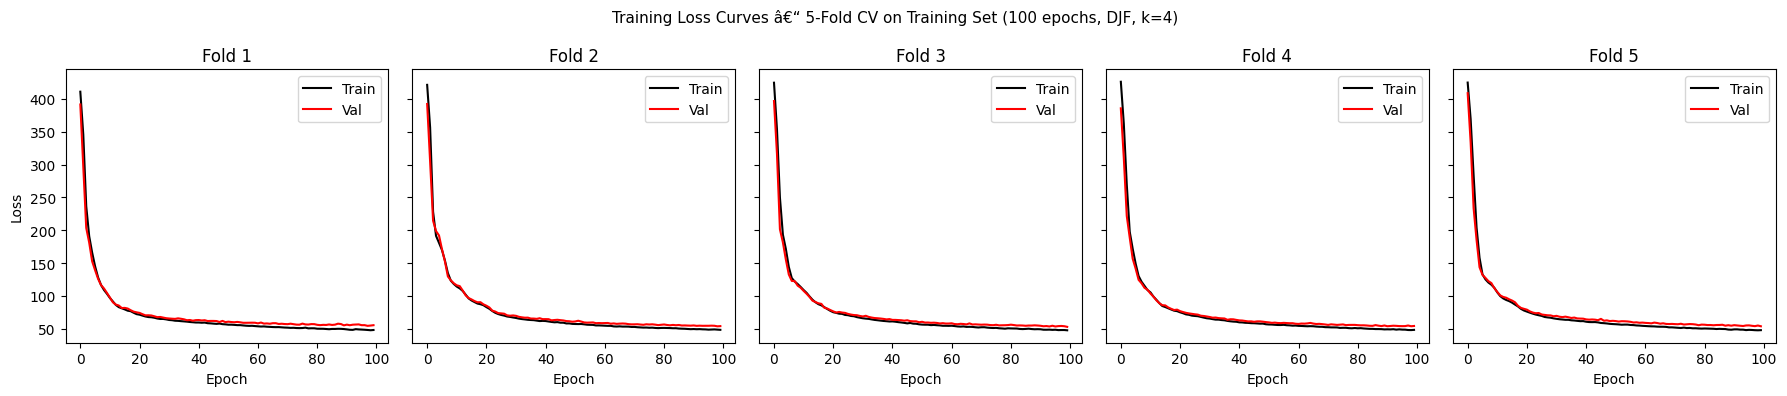

In [18]:
n_splits = 5

fig, axes = plt.subplots(1, n_splits, figsize=(18, 4), sharey=True)
for fold_idx, hist in enumerate(fold_histories):
    axes[fold_idx].plot(hist['loss'],     label='Train', color='black')
    axes[fold_idx].plot(hist['val_loss'], label='Val',   color='red')
    axes[fold_idx].set_title(f'Fold {fold_idx + 1}')
    axes[fold_idx].set_xlabel('Epoch')
    if fold_idx == 0:
        axes[fold_idx].set_ylabel('Loss')
    axes[fold_idx].legend()
plt.suptitle(f'Training Loss Curves â€“ 5-Fold CV on Training Set ({epochs} epochs, DJF, k={cluster_number})', fontsize=11)
plt.tight_layout()
plt.savefig(filepath + 'training_loss_curves.png', dpi=150)
plt.show()

## Evaluation

**Run encoder on FULL dataset to get cluster probabilities**

In [19]:
print("Running encoder on full dataset...")
[z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = encoder.predict(
    [X, dummy_full, y], batch_size=batch_size, verbose=0)
print(f"c_enc shape: {c_enc.shape}  (n_days x cluster_number)")

Running encoder on full dataset...
c_enc shape: (3791, 4)  (n_days x cluster_number)


### Maximum-likelihood cluster assignment

In [20]:
final_labels = np.argmax(c_enc, axis=1).astype(float)
print(f"Unique cluster labels: {np.unique(final_labels.astype(int))}")
for k in range(cluster_number):
    n = (final_labels == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(final_labels):.1f}%)")

Unique cluster labels: [0 1 2 3]
  Cluster 0: 963 days  (25.4%)
  Cluster 1: 768 days  (20.3%)
  Cluster 2: 1493 days  (39.4%)
  Cluster 3: 567 days  (15.0%)


### Cluster centres “ re-order by precipitation amount

In [21]:
# Sum precipitation over all grid points for each day  â†’ 1-D array
pr_total_daily = pr_spatial.sum(dim=['latitude', 'longitude']).values
assert len(pr_total_daily) == len(final_labels), (
    f"Length mismatch: pr_total_daily={len(pr_total_daily)}, "
    f"final_labels={len(final_labels)}")

precip_sum = (pd.DataFrame({'values': pr_total_daily, 'label': final_labels.astype(int)})
              .groupby('label')['values'].sum()
              .reset_index()
              .rename(columns={'label': 'index_old'})
              .sort_values('values', ascending=False)
              .reset_index(drop=True))
precip_sum['index_new'] = np.arange(len(precip_sum))

labels_reordered = final_labels.copy()
for i in range(len(final_labels)):
    new_label = precip_sum.loc[
        precip_sum['index_old'] == int(final_labels[i]), 'index_new'].values[0]
    labels_reordered[i] = new_label

print(precip_sum)

   index_old      values  index_new
0          1  26679640.0          0
1          3  15323686.0          1
2          0   9124972.0          2
3          2   8307318.5          3


### Save results

In [22]:
df = pd.DataFrame(data=c_enc)
df_reordered = df[precip_sum['index_old'].values.tolist()].copy()
df_reordered.columns = list(range(cluster_number))
df_reordered['label'] = labels_reordered

df['label'] = final_labels
df.to_csv(filepath + 'cluster_probabilities_' + str(cluster_number) + '.csv')
print("Cluster probabilities saved.")

Cluster probabilities saved.


In [23]:
z500_labels_preciporder = z500.assign_coords(label=('time', labels_reordered)) / weights
z500_labels             = z500.assign_coords(label=('time', final_labels))      / weights

means_preciporder = z500_labels_preciporder.groupby('label').mean()
means             = z500_labels.groupby('label').mean()

means_flat             = cf.reshape_data_for_clustering(means)
means_preciporder_flat = cf.reshape_data_for_clustering(means_preciporder)

np.save(filepath + 'cluster_centres_' + str(cluster_number) + '.npy', means_preciporder_flat)
print("Cluster centres saved.")

Cluster centres saved.


### Z500 Cluster Centres (re-ordered by precipitation)

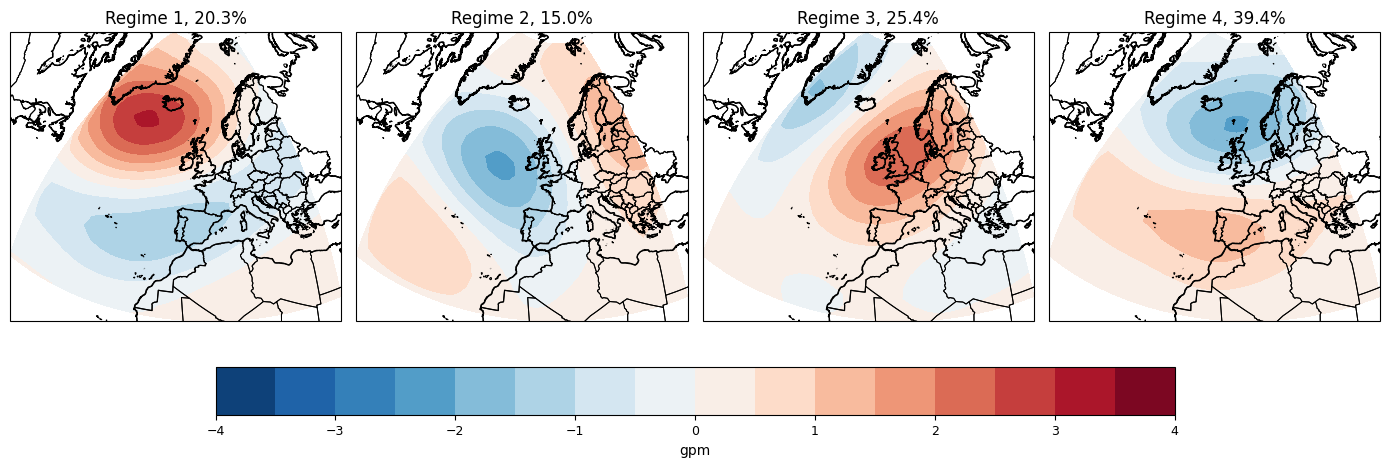

In [24]:
regime_names = [f'Regime {i+1}' for i in range(cluster_number)]

pr_cluster_vis = cf.visualise_contourplot(
    cluster_centers = means_preciporder,
    unit            = 'gpm',
    regime_names    = regime_names,
    vmin            = -4,
    vmax            = 4.5,
    steps           = 0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = z500_labels_preciporder.values,
    labels          = labels_reordered,
    borders         = True,
    col_number      = cluster_number,
    projection      = ccrs.Orthographic(0, 45))

plt.savefig(filepath + 'cluster_centres_' + str(cluster_number) + '.png', dpi=150)
plt.show()

### Odds Ratio map

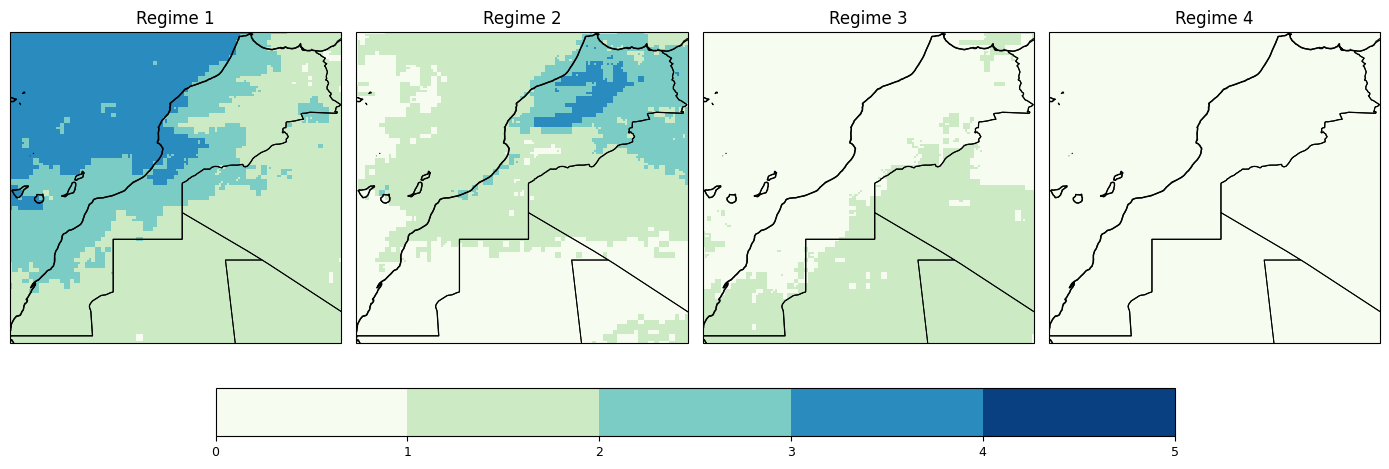

In [25]:
pr_qn95_ratio = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95,
    labels           = labels_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

pr_qn95_vis = cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin           = 0, vmax = 5, steps = 6,
    title          = f'Odds ratio â€“ 95th percentile precipitation (MSWEP DJF, k={cluster_number})',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_' + str(cluster_number) + '.png', dpi=150)
plt.show()

## Skill Scores

> **Evaluation strategy:**  
> - **CV scores** are computed from `out_of_fold_predictions_train`  
>   (K-Fold held-out data within the training set â€“ purely unseen during training).
> - **Holdout scores** are computed on the **30 % holdout set** that was never seen during training or CV.
> - Full-dataset scores via `c_enc` are also printed for reference.

In [26]:
# â”€â”€ Predict on holdout set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("Running encoder on holdout set...")
[_, _, _, _, c_holdout, _, r_holdout, _] = encoder.predict(
    [X_holdout, dummy_holdout, y_holdout], batch_size=batch_size, verbose=0)
print(f"c_holdout shape: {c_holdout.shape}")

# Reorder holdout predictions to match precipitation ordering
# (same column permutation as applied to the full dataset)
col_order = precip_sum['index_old'].values.tolist()
c_holdout_reordered = c_holdout[:, col_order]

Running encoder on holdout set...
c_holdout shape: (1138, 4)


In [27]:
# Select precipitation data for the holdout days 
pr_spatial_holdout   = pr_spatial.isel(time=holdout_idx)
threshold_qn95_holdout = threshold_qn95.isel(time=holdout_idx)

# Holdout labels (reordered)
labels_holdout_raw      = np.argmax(c_holdout, axis=1).astype(float)
labels_holdout_reordered = np.zeros_like(labels_holdout_raw)
for i in range(len(labels_holdout_raw)):
    new_label = precip_sum.loc[
        precip_sum['index_old'] == int(labels_holdout_raw[i]), 'index_new'].values[0]
    labels_holdout_reordered[i] = new_label

In [28]:
print("=== BSS on CV OUT-OF-FOLD (training-set held-out data) ===")
bss_95_cv = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = out_of_fold_predictions_train,
    pr_spatial               = pr_spatial.isel(time=train_idx))
print(f"BSS 95th percentile (CV): {bss_95_cv:.4f}")

bss_cluster_cv = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = np.array(pr_labels['labels'])[train_idx],
    z500_cluster_probabilities = out_of_fold_predictions_train)
print(f"BSS cluster (CV):         {bss_cluster_cv:.4f}")

print("\n=== BSS on HOLDOUT SET (30 % unseen) ===")
bss_95_holdout = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = c_holdout_reordered,
    pr_spatial               = pr_spatial_holdout)
print(f"BSS 95th percentile (holdout): {bss_95_holdout:.4f}")

bss_cluster_holdout = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = np.array(pr_labels['labels'])[holdout_idx],
    z500_cluster_probabilities = c_holdout_reordered)
print(f"BSS cluster (holdout):         {bss_cluster_holdout:.4f}")

bss_tercile_holdout = sf.calculate_tercile_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = c_holdout_reordered,
    pr_spatial               = pr_spatial_holdout)
print(f"BSS tercile (holdout, spatial mean): {float(bss_tercile_holdout.mean()):.4f}")
print(f"BSS tercile (holdout, spatial map shape): {bss_tercile_holdout.shape}")

print("\n=== BSS on FULL DATASET (c_enc, for reference) ===")
bss_95_full = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500      = cluster_number,
    z500_cluster_probabilities = c_enc,
    pr_spatial               = pr_spatial)
print(f"BSS 95th percentile (full): {bss_95_full:.4f}")

# Save results as a CSV
df_scores = pd.DataFrame({
    'k':                    [cluster_number],
    'bss_95_cv':            [bss_95_cv],
    'bss_cluster_cv':       [bss_cluster_cv],
    'bss_95_holdout':       [bss_95_holdout],
    'bss_cluster_holdout':  [bss_cluster_holdout],
    'bss_tercile_holdout':  [float(bss_tercile_holdout.mean())],
    'bss_95_full':          [bss_95_full],
    'best_fold':            [best_fold],
    'best_val_loss':        [best_val_loss]
})
df_scores.to_csv(filepath + 'skill_score.csv', index=False)
print("\nSkill scores saved to skill_score.csv")

=== BSS on CV OUT-OF-FOLD (training-set held-out data) ===
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
BSS 95th percentile (CV): 0.0287
BSS cluster (CV):         0.0839

=== BSS on HOLDOUT SET (30 % unseen) ===
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
BSS 95th percentile (holdout): 0.1232
BSS cluster (holdout):         0.2207
BSS tercile (holdout, spatial mean): 0.0808
BSS tercile (holdout, spatial map shape): (150, 160)

=== BSS on FULL DATASET (c_enc, for reference) ===
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
BSS 95th percentile (full): 0.1061

Skill scores saved to skill_score.csv


### Odds Ratio â€“ Holdout set only

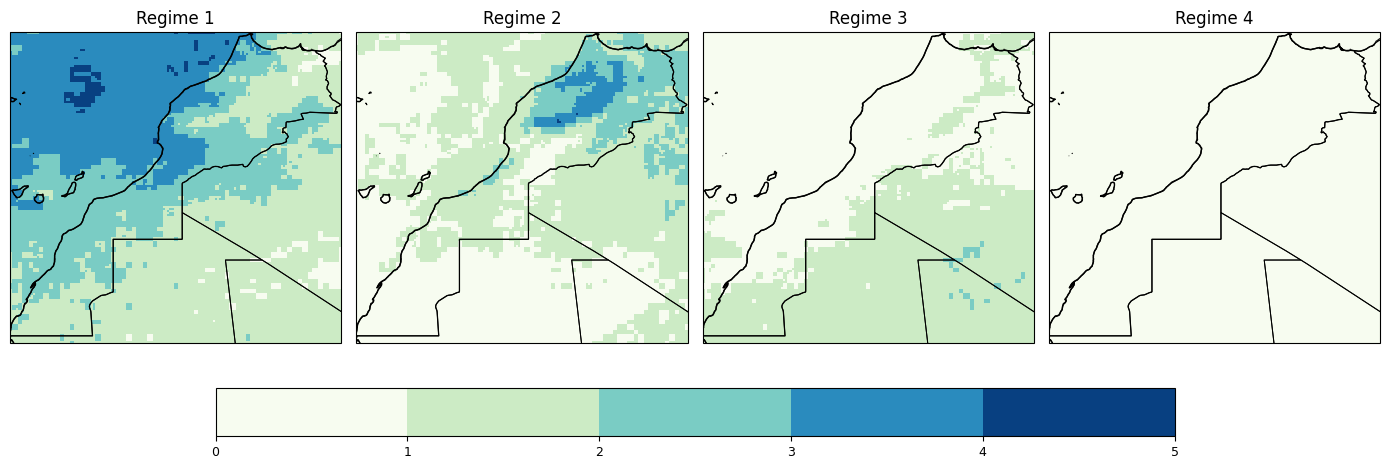

In [29]:
pr_qn95_ratio_holdout = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_holdout,
    labels           = labels_holdout_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_holdout,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin           = 0, vmax = 5, steps = 6,
    title          = f'Odds ratio â€“ 95th pct precip (MSWEP DJF holdout, k={cluster_number})',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_holdout_' + str(cluster_number) + '.png', dpi=150)
plt.show()

### Verification “ case-by-case prediction on holdout set

In [30]:
predicted_precip_holdout = np.argmax(r_holdout, axis=1)
real_precip_holdout      = np.argmax(y_holdout, axis=1)

accuracy = (predicted_precip_holdout == real_precip_holdout).mean()
print(f"Precipitation Cluster Accuracy (holdout): {accuracy*100:.1f}%")
print(f"({(predicted_precip_holdout == real_precip_holdout).sum()} correct out of {len(real_precip_holdout)} days)")
print(f"Random baseline would be: {100/pr_cluster_number:.1f}%")

# Table “ highest-confidence correct / wrong predictions
confidence    = r_holdout.max(axis=1)
correct_mask  = (predicted_precip_holdout == real_precip_holdout)

n_show = min(3, correct_mask.sum(), (~correct_mask).sum())

correct_idx   = np.where(correct_mask)[0][np.argsort(confidence[correct_mask])[-n_show:]]
incorrect_idx = np.where(~correct_mask)[0][np.argsort(confidence[~correct_mask])[-n_show:]]

print(f"\n{'Day':>6} | {'Date':>12} | {'Real Cluster':>12} | {'Predicted':>10} | {'Confidence':>12} | {'Result':>8}")
print("-" * 75)
for idx, verdict in zip(
    np.concatenate([correct_idx, incorrect_idx]),
    ['CORRECT']*n_show + ['WRONG']*n_show):
    date = str(pr_spatial_holdout.time.values[idx])[:10]
    print(f"{holdout_idx[idx]:>6} | {date:>12} | {real_precip_holdout[idx]:>12} | {predicted_precip_holdout[idx]:>10} | {confidence[idx]:>11.1%} | {verdict:>8}")

Precipitation Cluster Accuracy (holdout): 84.3%
(959 correct out of 1138 days)
Random baseline would be: 25.0%

   Day |         Date | Real Cluster |  Predicted |   Confidence |   Result
---------------------------------------------------------------------------
  2115 |   2002-02-09 |            3 |          3 |      100.0% |  CORRECT
  3585 |   2018-12-07 |            3 |          3 |      100.0% |  CORRECT
  3602 |   2018-12-24 |            3 |          3 |      100.0% |  CORRECT
    58 |   1979-02-28 |            0 |          3 |      100.0% |    WRONG
  2211 |   2003-02-15 |            0 |          3 |      100.0% |    WRONG
   949 |   1989-02-16 |            1 |          3 |      100.0% |    WRONG
